In [3]:
print("hi")

hi


In [5]:
import sqlite3 # Standard Python library for SQLite database interaction
import requests # Library for making HTTP requests (to download the SQL script)
from langchain_community.utilities.sql_database import SQLDatabase # LangChain utility to interact with SQL databases
from sqlalchemy import create_engine # SQLAlchemy function to create a database engine
from sqlalchemy.pool import StaticPool # SQLAlchemy connection pool class for in-memory databases

def get_engine_for_chinook_db():
    """Pull sql file, populate in-memory database, and create engine."""
    # URL to the raw SQL script for the Chinook database
    url = "https://raw.githubusercontent.com/lerocha/chinook-database/master/ChinookDatabase/DataSources/Chinook_Sqlite.sql"
    
    # Fetch the SQL script content from the URL
    response = requests.get(url)
    sql_script = response.text

    # Create an in-memory SQLite database connection.
    # `check_same_thread=False` is important for SQLAlchemy's StaticPool.
    connection = sqlite3.connect(":memory:", check_same_thread=False)
    
    # Execute the SQL script to populate the in-memory database with Chinook data
    connection.executescript(sql_script)
    
    # Create a SQLAlchemy engine for the in-memory SQLite database.
    # `creator=lambda: connection` tells SQLAlchemy how to get a new connection.
    # `poolclass=StaticPool` is used for in-memory databases, ensuring the same connection is reused.
    # `connect_args` are passed directly to the `sqlite3.connect` function.
    return create_engine(
        "sqlite://",
        creator=lambda: connection,
        poolclass=StaticPool,
        connect_args={"check_same_thread": False},
    )

# Get the SQLAlchemy engine for our Chinook database
engine = get_engine_for_chinook_db()

# Create a LangChain SQLDatabase utility instance from the engine.
# This utility will help our agents interact with the database via SQL queries.
db = SQLDatabase(engine)

In [6]:
from langgraph.checkpoint.memory import MemorySaver # For short-term memory (thread-level state persistence)
from langgraph.store.memory import InMemoryStore # For long-term memory (storing user preferences)

# Initializing `InMemoryStore` for long-term memory. 
# This store will hold user-specific data like music preferences across sessions.
in_memory_store = InMemoryStore()

# Initializing `MemorySaver` for short-term (thread-level) memory. 
# This checkpointer saves the graph's state after each step, allowing for restarts or interruptions within a thread.
checkpointer = MemorySaver()

In [7]:
from typing_extensions import TypedDict # For defining dictionaries with type hints
from typing import Annotated, List # For type hinting lists and adding annotations
from langgraph.graph.message import AnyMessage, add_messages # For managing messages in the graph state
from langgraph.managed.is_last_step import RemainingSteps # For tracking recursion limits

class State(TypedDict):
    """Represents the state of our LangGraph agent."""
    # customer_id: Stores the unique identifier for the current customer.
    customer_id: str
    
    # messages: A list of messages that form the conversation history.
    # Annotated with `add_messages` to ensure new messages are appended rather than overwritten.
    messages: Annotated[list[AnyMessage], add_messages]
    
    # loaded_memory: Stores information loaded from the long-term memory store, 
    # typically user preferences or historical context.
    loaded_memory: str
    
    # remaining_steps: Used by LangGraph to track the number of allowed steps 
    # to prevent infinite loops in cyclic graphs.
    remaining_steps: RemainingSteps 

In [8]:
from langchain_core.tools import tool # Decorator to define a function as a LangChain tool
import ast # Module to safely evaluate strings containing Python literal structures

@tool
def get_albums_by_artist(artist: str):
    """Get albums by an artist."""
    # Execute a SQL query to retrieve album titles and artist names
    # from the Album and Artist tables, joining them and filtering by artist name.
    # `db.run` is a utility from LangChain's SQLDatabase to execute queries.
    # `include_columns=True` ensures column names are included in the result for better readability.
    return db.run(
        f"""
        SELECT Album.Title, Artist.Name 
        FROM Album 
        JOIN Artist ON Album.ArtistId = Artist.ArtistId 
        WHERE Artist.Name LIKE '%{artist}%';
        """,
        include_columns=True
    )

@tool
def get_tracks_by_artist(artist: str):
    """Get songs by an artist (or similar artists)."""
    # Execute a SQL query to find tracks (songs) by a given artist, or similar artists.
    # It joins Album, Artist, and Track tables to get song names and artist names.
    return db.run(
        f"""
        SELECT Track.Name as SongName, Artist.Name as ArtistName 
        FROM Album 
        LEFT JOIN Artist ON Album.ArtistId = Artist.ArtistId 
        LEFT JOIN Track ON Track.AlbumId = Album.AlbumId 
        WHERE Artist.Name LIKE '%{artist}%';
        """,
        include_columns=True
    )

@tool
def get_songs_by_genre(genre: str):
    """
    Fetch songs from the database that match a specific genre.
    
    Args:
        genre (str): The genre of the songs to fetch.
    
    Returns:
        list[dict]: A list of songs that match the specified genre.
    """
    # First, find the GenreId for the given genre name.
    genre_id_query = f"SELECT GenreId FROM Genre WHERE Name LIKE '%{genre}%'"
    genre_ids = db.run(genre_id_query)
    
    # If no genre IDs are found, return an informative message.
    if not genre_ids:
        return f"No songs found for the genre: {genre}"
    
    # Safely evaluate the string result from db.run to get a list of tuples.
    genre_ids = ast.literal_eval(genre_ids)
    # Extract just the GenreId values and join them into a comma-separated string for the IN clause.
    genre_id_list = ", ".join(str(gid[0]) for gid in genre_ids)

    # Construct the query to get songs for the found genre IDs.
    # It joins Track, Album, and Artist tables and limits the results to 8.
    songs_query = f"""
        SELECT Track.Name as SongName, Artist.Name as ArtistName
        FROM Track
        LEFT JOIN Album ON Track.AlbumId = Album.AlbumId
        LEFT JOIN Artist ON Album.ArtistId = Artist.ArtistId
        WHERE Track.GenreId IN ({genre_id_list})
        GROUP BY Artist.Name
        LIMIT 8;
    """
    songs = db.run(songs_query, include_columns=True)
    
    # If no songs are found for the genre, return an informative message.
    if not songs:
        return f"No songs found for the genre: {genre}"
        
    # Safely evaluate the string result and format it into a list of dictionaries.
    formatted_songs = ast.literal_eval(songs)
    return [
        {"Song": song["SongName"], "Artist": song["ArtistName"]}
        for song in formatted_songs
    ]

@tool
def check_for_songs(song_title):
    """Check if a song exists by its name."""
    # Execute a SQL query to check for the existence of a song by its title.
    return db.run(
        f"""
        SELECT * FROM Track WHERE Name LIKE '%{song_title}%';
        """,
        include_columns=True
    )

# Aggregate all music-related tools into a list.
music_tools = [get_albums_by_artist, get_tracks_by_artist, get_songs_by_genre, check_for_songs]

# Bind the tools to our ChatOpenAI model.
# This step configures the LLM so it knows about the available tools and their schemas,
# allowing it to generate tool calls when appropriate based on the user's query.
llm_with_music_tools = llm.bind_tools(music_tools)

In [9]:
from langgraph.prebuilt import ToolNode # Pre-built node for executing tools

# Create a ToolNode instance. This node will automatically execute any tool calls 
# generated by an LLM that is bound to these tools.
music_tool_node = ToolNode(music_tools)

In [10]:
from langchain_core.messages import ToolMessage, SystemMessage, HumanMessage # Message types for conversation history
from langchain_core.runnables import RunnableConfig # For configuration parameters passed to runnables

# Define the system prompt for the music assistant.
# This prompt provides instructions and persona for the LLM.
# It emphasizes the agent's role, core responsibilities, and search guidelines.
# The `memory` placeholder allows us to inject user preferences from long-term memory.
def generate_music_assistant_prompt(memory: str = "None") -> str:
    return f"""
    You are a member of the assistant team, your role specifically is to focused on helping customers discover and learn about music in our digital catalog. 
    If you are unable to find playlists, songs, or albums associated with an artist, it is okay. 
    Just inform the customer that the catalog does not have any playlists, songs, or albums associated with that artist.
    You also have context on any saved user preferences, helping you to tailor your response. 
    
    CORE RESPONSIBILITIES:
    - Search and provide accurate information about songs, albums, artists, and playlists
    - Offer relevant recommendations based on customer interests
    - Handle music-related queries with attention to detail
    - Help customers discover new music they might enjoy
    - You are routed only when there are questions related to music catalog; ignore other questions. 
    
    SEARCH GUIDELINES:
    1. Always perform thorough searches before concluding something is unavailable
    2. If exact matches aren't found, try:
       - Checking for alternative spellings
       - Looking for similar artist names
       - Searching by partial matches
       - Checking different versions/remixes
    3. When providing song lists:
       - Include the artist name with each song
       - Mention the album when relevant
       - Note if it's part of any playlists
       - Indicate if there are multiple versions
    
    Additional context is provided below: 

    Prior saved user preferences: {memory}
    
    Message history is also attached.  
    """

# Define the music_assistant node function.
# This function receives the current `State` and `RunnableConfig`.
def music_assistant(state: State, config: RunnableConfig): 

    # Fetch long-term memory (user preferences) from the state.
    # If `loaded_memory` is not present in the state, default to "None".
    memory = "None" 
    if "loaded_memory" in state: 
        memory = state["loaded_memory"]

    # Generate the system prompt for the music assistant, injecting the loaded memory.
    music_assistant_prompt = generate_music_assistant_prompt(memory)

    # Invoke the LLM (`llm_with_music_tools`) with the system prompt and the current message history.
    # The LLM will decide whether to call a tool or generate a final response.
    response = llm_with_music_tools.invoke([SystemMessage(music_assistant_prompt)] + state["messages"])
    
    # Update the state by appending the LLM's response to the `messages` list.
    # The `add_messages` annotation in `State` ensures this is appended correctly.
    return {"messages": [response]}

In [11]:
# Define a conditional edge function named `should_continue`.
# This function determines the next step in the graph based on the LLM's response.
def should_continue(state: State, config: RunnableConfig):
    # Get the list of messages from the current state.
    messages = state["messages"]
    # Get the last message, which is the response from the `music_assistant` LLM.
    last_message = messages[-1]
    
    # Check if the last message contains any tool calls.
    # LLMs generate `tool_calls` when they decide to use a function.
    if not last_message.tool_calls:
        # If there are no tool calls, it means the LLM has generated a final answer.
        # In this case, the sub-agent's work is done, so we return "end" to signal completion.
        return "end"
    # Otherwise, if there are tool calls,
    else:
        # We need to execute the tool(s). So, we return "continue" to route to the tool execution node.
        return "continue"

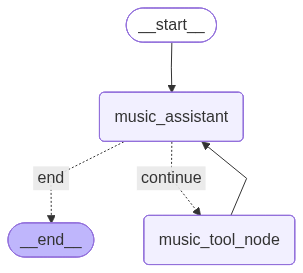

In [12]:
from langgraph.graph import StateGraph, START, END # Core LangGraph classes and special node names
from utils import show_graph # Utility function to visualize the graph (assumed to be in a utils.py file)

# Initialize a StateGraph with our defined `State` schema.
# This tells LangGraph how the data will flow and be managed within the graph.
music_workflow = StateGraph(State)

# Add the 'music_assistant' node to the graph.
# This node is responsible for the LLM's reasoning and generating tool calls or final responses.
music_workflow.add_node("music_assistant", music_assistant)

# Add the 'music_tool_node' to the graph.
# This node is responsible for executing the tools when requested by the LLM.
music_workflow.add_node("music_tool_node", music_tool_node)


# Define the starting point of the graph.
# All queries will initially enter the 'music_assistant' node.
music_workflow.add_edge(START, "music_assistant")

# Add a conditional edge from 'music_assistant'.
# The `should_continue` function will be called to determine the next node.
music_workflow.add_conditional_edges(
    "music_assistant", # Source node
    should_continue,   # Conditional function to call
    {
        # If `should_continue` returns "continue", route to `music_tool_node`.
        "continue": "music_tool_node",
        # If `should_continue` returns "end", terminate the graph execution.
        "end": END,
    },
)

# Add a normal edge from 'music_tool_node' back to 'music_assistant'.
# After a tool is executed, the result is fed back to the LLM for further reasoning 
# or to formulate a final response (ReAct loop).
music_workflow.add_edge("music_tool_node", "music_assistant")

# Compile the graph into a runnable object.
# `name`: A unique identifier for this compiled graph (useful for debugging and logging).
# `checkpointer`: The short-term memory mechanism (MemorySaver) for thread-specific state.
# `store`: The long-term memory mechanism (InMemoryStore) for persistent user data.
music_catalog_subagent = music_workflow.compile(name="music_catalog_subagent", checkpointer=checkpointer, store = in_memory_store)

# Display a visualization of the compiled graph.
show_graph(music_catalog_subagent)

In [13]:
import uuid # Module for generating unique identifiers

# Generate a unique thread ID for this conversation.
# This ensures that the conversation state is isolated and can be resumed later.
thread_id = uuid.uuid4()

# Define the customer's question.
question = "I like the Rolling Stones. What songs do you recommend by them or by other artists that I might like?"

# Create the configuration dictionary for invoking the graph.
# The `thread_id` is essential for the checkpointer to manage state.
config = {"configurable": {"thread_id": thread_id}}

# Invoke the `music_catalog_subagent` with the initial human message and configuration.
# The `invoke` method runs the graph to completion and returns the final state.
result = music_catalog_subagent.invoke({"messages": [HumanMessage(content=question)]}, config=config)

# Iterate through the messages in the final state and print them for observation.
# `pretty_print()` provides a formatted output of the message content and role.
for message in result["messages"]:
   message.pretty_print()

INFO:httpx:HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


================================ Human Message =================================

I like the Rolling Stones. What songs do you recommend by them or by other artists that I might like?
================================== Ai Message ==================================
Tool Calls:
  get_tracks_by_artist (fc_38de6430-54cb-4cc8-be29-20134a3006fe)
 Call ID: fc_38de6430-54cb-4cc8-be29-20134a3006fe
  Args:
    artist: Rolling Stones
================================= Tool Message =================================
Name: get_tracks_by_artist

[{'SongName': 'Time Is On My Side', 'ArtistName': 'The Rolling Stones'}, {'SongName': 'Heart Of Stone', 'ArtistName': 'The Rolling Stones'}, {'SongName': 'Play With Fire', 'ArtistName': 'The Rolling Stones'}, {'SongName': 'Satisfaction', 'ArtistName': 'The Rolling Stones'}, {'SongName': 'As Tears Go By', 'ArtistName': 'The Rolling Stones'}, {'SongName': 'Get Off Of My Cloud', 'ArtistName': 'The Rolling Stones'}, {'SongName': "Mother's Little Helper", 'ArtistNa

In [14]:
from langchain_core.tools import tool # Import the tool decorator again

@tool 
def get_invoices_by_customer_sorted_by_date(customer_id: str) -> list[dict]:
    """
    Look up all invoices for a customer using their ID.
    The invoices are sorted in descending order by invoice date, which helps when the customer wants to view their most recent/oldest invoice, or if 
    they want to view invoices within a specific date range.
    
    Args:
        customer_id (str): customer_id, which serves as the identifier.
    
    Returns:
        list[dict]: A list of invoices for the customer.
    """
    # Executes a SQL query to retrieve all invoice details for a given customer ID,
    # ordered by invoice date in descending order (most recent first).
    return db.run(f"SELECT * FROM Invoice WHERE CustomerId = {customer_id} ORDER BY InvoiceDate DESC;")


@tool 
def get_invoices_sorted_by_unit_price(customer_id: str) -> list[dict]:
    """
    Use this tool when the customer wants to know the details of one of their invoices based on the unit price/cost of the invoice.
    This tool looks up all invoices for a customer, and sorts the unit price from highest to lowest. In order to find the invoice associated with the customer, 
    we need to know the customer ID.
    
    Args:
        customer_id (str): customer_id, which serves as the identifier.
    
    Returns:
        list[dict]: A list of invoices sorted by unit price.
    """
    # Executes a SQL query to retrieve invoice details along with the unit price of items in those invoices,
    # for a given customer ID, ordered by unit price in descending order (highest unit price first).
    query = f"""
        SELECT Invoice.*, InvoiceLine.UnitPrice
        FROM Invoice
        JOIN InvoiceLine ON Invoice.InvoiceId = InvoiceLine.InvoiceId
        WHERE Invoice.CustomerId = {customer_id}
        ORDER BY InvoiceLine.UnitPrice DESC;
    """
    return db.run(query)


@tool
def get_employee_by_invoice_and_customer(invoice_id: str, customer_id: str) -> dict:
    """
    This tool will take in an invoice ID and a customer ID and return the employee information associated with the invoice.

    Args:
        invoice_id (int): The ID of the specific invoice.
        customer_id (str): customer_id, which serves as the identifier.

    Returns:
        dict: Information about the employee associated with the invoice.
    """

    # Executes a SQL query to find the employee associated with a specific invoice and customer.
    # It joins Employee, Customer, and Invoice tables to retrieve employee first name, title, and email.
    query = f"""
        SELECT Employee.FirstName, Employee.Title, Employee.Email
        FROM Employee
        JOIN Customer ON Customer.SupportRepId = Employee.EmployeeId
        JOIN Invoice ON Invoice.CustomerId = Customer.CustomerId
        WHERE Invoice.InvoiceId = ({invoice_id}) AND Invoice.CustomerId = ({customer_id});
    """
    
    employee_info = db.run(query, include_columns=True)
    
    # Checks if any employee information was found.
    if not employee_info:
        return f"No employee found for invoice ID {invoice_id} and customer identifier {customer_id}."
    return employee_info

# Aggregate all invoice-related tools into a list.
invoice_tools = [get_invoices_by_customer_sorted_by_date, get_invoices_sorted_by_unit_price, get_employee_by_invoice_and_customer]

In [15]:
# Define the system prompt for the invoice information sub-agent.
# This prompt sets the persona and core responsibilities for the LLM within this sub-agent's domain.
# It explicitly lists the tools available to this agent and provides guidelines for their use.
invoice_subagent_prompt = """
    You are a subagent among a team of assistants. You are specialized for retrieving and processing invoice information. You are routed for invoice-related portion of the questions, so only respond to them.. 

    You have access to three tools. These tools enable you to retrieve and process invoice information from the database. Here are the tools:
    - get_invoices_by_customer_sorted_by_date: This tool retrieves all invoices for a customer, sorted by invoice date.
    - get_invoices_sorted_by_unit_price: This tool retrieves all invoices for a customer, sorted by unit price.
    - get_employee_by_invoice_and_customer: This tool retrieves the employee information associated with an invoice and a customer.
    
    If you are unable to retrieve the invoice information, inform the customer you are unable to retrieve the information, and ask if they would like to search for something else.
    
    CORE RESPONSIBILITIES:
    - Retrieve and process invoice information from the database
    - Provide detailed information about invoices, including customer details, invoice dates, total amounts, employees associated with the invoice, etc. when the customer asks for it.
    - Always maintain a professional, friendly, and patient demeanor
    
    You may have additional context that you should use to help answer the customer's query. It will be provided to you below:
    """

In [16]:
from langgraph.prebuilt import create_react_agent # Import the pre-built ReAct agent creator

# Define the invoice information subagent using the pre-built `create_react_agent`.
# This function internally sets up the nodes (LLM and ToolNode) and edges for a ReAct loop.
invoice_information_subagent = create_react_agent(
    llm,                          # The language model to use for reasoning
    tools=invoice_tools,            # The list of tools available to this agent
    name="invoice_information_subagent", # A unique name for this agent within the graph
    prompt=invoice_subagent_prompt, # The system prompt for this agent's persona and instructions
    state_schema=State,             # The shared state schema for the graph
    checkpointer=checkpointer,      # The checkpointer for short-term (thread-level) memory
    store = in_memory_store         # The in-memory store for long-term user data
)

C:\Users\SNA\AppData\Local\Temp\ipykernel_34156\2571326119.py:5: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  invoice_information_subagent = create_react_agent(


In [17]:
thread_id = uuid.uuid4() # Generate a new unique thread ID for this test conversation.

# Define a sample question for the invoice sub-agent.
question = "My customer id is 1. What was my most recent invoice, and who was the employee that helped me with it?"

# Set up the configuration with the thread ID.
config = {"configurable": {"thread_id": thread_id}}

# Invoke the invoice sub-agent with the question and configuration.
result = invoice_information_subagent.invoke({"messages": [HumanMessage(content=question)]}, config=config)

# Print the conversation history from the result for verification.
for message in result["messages"]:
    message.pretty_print()

INFO:httpx:HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


================================ Human Message =================================

My customer id is 1. What was my most recent invoice, and who was the employee that helped me with it?
================================== Ai Message ==================================
Name: invoice_information_subagent
Tool Calls:
  get_invoices_by_customer_sorted_by_date (fc_af0f8aac-017f-47d3-935d-bc8b86e7127e)
 Call ID: fc_af0f8aac-017f-47d3-935d-bc8b86e7127e
  Args:
    customer_id: 1
================================= Tool Message =================================
Name: get_invoices_by_customer_sorted_by_date

[(382, 1, '2025-08-07 00:00:00', 'Av. Brigadeiro Faria Lima, 2170', 'São José dos Campos', 'SP', 'Brazil', '12227-000', 8.91), (327, 1, '2024-12-07 00:00:00', 'Av. Brigadeiro Faria Lima, 2170', 'São José dos Campos', 'SP', 'Brazil', '12227-000', 13.86), (316, 1, '2024-10-27 00:00:00', 'Av. Brigadeiro Faria Lima, 2170', 'São José dos Campos', 'SP', 'Brazil', '12227-000', 1.98), (195, 1, '2023-05-

In [18]:
supervisor_prompt = """You are an expert customer support assistant for a digital music store. 
You are dedicated to providing exceptional service and ensuring customer queries are answered thoroughly. 
You have a team of subagents that you can use to help answer queries from customers. 
Your primary role is to serve as a supervisor/planner for this multi-agent team that helps answer queries from customers. 

Your team is composed of two subagents that you can use to help answer the customer's request:
1. music_catalog_information_subagent: this subagent has access to user's saved music preferences. It can also retrieve information about the digital music store's music 
catalog (albums, tracks, songs, etc.) from the database. 
3. invoice_information_subagent: this subagent is able to retrieve information about a customer's past purchases or invoices 
from the database. 

Based on the existing steps that have been taken in the messages, your role is to generate the next subagent that needs to be called. 
This could be one step in an inquiry that needs multiple sub-agent calls. """

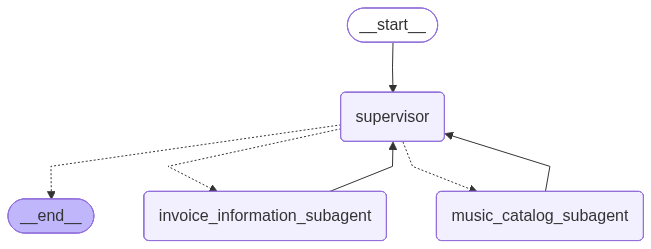

In [19]:
from langgraph_supervisor import create_supervisor # Import the pre-built supervisor creator

# Create the supervisor workflow using the `create_supervisor` utility.
# This function dynamically sets up the graph to route between the provided agents.
supervisor_prebuilt_workflow = create_supervisor(
    agents=[invoice_information_subagent, music_catalog_subagent], # List of sub-agents the supervisor can route to
    output_mode="last_message", # Specifies that the supervisor should output only the last message from the routed agent.
                                # Alternative is "full_history" to get all messages from the sub-agent.
    model=llm,                # The LLM to act as the supervisor (for routing decisions).
    prompt=(supervisor_prompt), # The system prompt guiding the supervisor's behavior.
    state_schema=State          # The shared state schema for the entire multi-agent graph.
)

# Compile the supervisor workflow into a runnable object.
# This makes it ready for invocation and integrates it with our memory systems.
supervisor_prebuilt = supervisor_prebuilt_workflow.compile(name="music_catalog_subagent", checkpointer=checkpointer, store=in_memory_store)

# Display a visualization of the compiled supervisor graph.
# Notice how the supervisor acts as the central hub, directing traffic to its sub-agents.
show_graph(supervisor_prebuilt)

In [20]:
thread_id = uuid.uuid4() # Generate a fresh thread ID for this conversation.

# Define a question that involves both invoice and music information.
question = "My customer ID is 1. How much was my most recent purchase? What albums do you have by U2?"

# Configure the invocation with the thread ID.
config = {"configurable": {"thread_id": thread_id}}

# Invoke the `supervisor_prebuilt` graph with the human message.
# The supervisor will analyze the question, route it to the appropriate sub-agent(s), 
# and return the final response from the last active agent.
result = supervisor_prebuilt.invoke({"messages": [HumanMessage(content=question)]}, config=config)

# Print the messages from the resulting state to see the conversation flow and final answer.
for message in result["messages"]:
    message.pretty_print()

INFO:httpx:HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
INFO:groq._base_client:Retrying request to /openai/v1/chat/completions in 3.000000 seconds
INFO:httpx:HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


================================ Human Message =================================

My customer ID is 1. How much was my most recent purchase? What albums do you have by U2?
================================== Ai Message ==================================
Name: supervisor
Tool Calls:
  transfer_to_invoice_information_subagent (fc_d02e2028-b9af-4f66-bf36-bf32bcd35eb2)
 Call ID: fc_d02e2028-b9af-4f66-bf36-bf32bcd35eb2
  Args:
    customer_id: 1
================================= Tool Message =================================
Name: transfer_to_invoice_information_subagent

Successfully transferred to invoice_information_subagent
================================== Ai Message ==================================
Name: invoice_information_subagent

Your most recent purchase (invoice #382) was for **$8.91**.

I’m focused on helping with invoice‑related information, so I don’t have details about U2 albums. If you have any other questions about your invoices or need further assistance, just let me kn

In [21]:
from pydantic import BaseModel, Field # Pydantic for defining data schemas and field validation

# Define a Pydantic BaseModel to structure the expected user input for account information.
# This helps the LLM to parse specific entities (identifier) from free-form text.
class UserInput(BaseModel):
    """Schema for parsing user-provided account information."""
    # `identifier` field: Expects a string, with a description for the LLM to understand its purpose.
    identifier: str = Field(description = "Identifier, which can be a customer ID, email, or phone number.")

# Bind the Pydantic schema to our LLM using `with_structured_output`.
# This forces the LLM to generate output that conforms to the `UserInput` schema, making parsing reliable.
structured_llm = llm.with_structured_output(schema=UserInput)

# Define a system prompt specifically for the structured LLM.
# This prompt instructs the LLM on how to extract the customer identifier from messages.
structured_system_prompt = """You are a customer service representative responsible for extracting customer identifier.\n 
Only extract the customer's account information from the message history. 
If they haven't provided the information yet, return an empty string for the file"""

In [22]:
from typing import Optional # For type hinting optional values

# Helper function to retrieve a customer ID from various identifiers (ID, phone, email).
def get_customer_id_from_identifier(identifier: str) -> Optional[int]:
    """
    Retrieve Customer ID using an identifier, which can be a customer ID, email, or phone number.
    
    Args:
        identifier (str): The identifier can be customer ID, email, or phone.
    
    Returns:
        Optional[int]: The CustomerId if found, otherwise None.
    """
    # Check if the identifier is purely numeric, indicating a direct customer ID.
    if identifier.isdigit():
        return int(identifier)
    
    # Check if the identifier starts with '+', suggesting a phone number.
    elif identifier[0] == "+":
        query = f"SELECT CustomerId FROM Customer WHERE Phone = '{identifier}';"
        result = db.run(query)
        formatted_result = ast.literal_eval(result) # Safely evaluate string to list/tuple
        if formatted_result:
            return formatted_result[0][0] # Return the first CustomerId found
    
    # Check if the identifier contains '@', suggesting an email address.
    elif "@" in identifier:
        query = f"SELECT CustomerId FROM Customer WHERE Email = '{identifier}';"
        result = db.run(query)
        formatted_result = ast.literal_eval(result)
        if formatted_result:
            return formatted_result[0][0] # Return the first CustomerId found
    
    # If no matching identifier type is found or no ID is retrieved, return None.
    return None 

In [23]:
# Define the `verify_info` node function.
# This node is responsible for verifying the customer's identity based on their input.
def verify_info(state: State, config: RunnableConfig):
    """Verify the customer's account by parsing their input and matching it with the database."""

    # Check if a customer_id is already present in the state.
    # If it is, verification is complete, and the node does nothing (passes).
    if state.get("customer_id") is None: 
        # System instructions for the verification LLM.
        system_instructions = """You are a music store agent, where you are trying to verify the customer identity 
        as the first step of the customer support process. 
        Only after their account is verified, you would be able to support them on resolving the issue. 
        In order to verify their identity, one of their customer ID, email, or phone number needs to be provided.
        If the customer has not provided the information yet, please ask them for it.
        If they have provided the identifier but cannot be found, please ask them to revise it."""

        # Get the most recent user message from the state.
        user_input = state["messages"][-1] 
    
        # Use the structured LLM to parse the user's input for an identifier.
        # It combines the structured system prompt with the user's message.
        parsed_info = structured_llm.invoke([SystemMessage(content=structured_system_prompt)] + [user_input])
    
        # Extract the identified identifier string.
        identifier = parsed_info.identifier
    
        customer_id = "" # Initialize customer_id as an empty string.
        # Attempt to find the customer ID in the database using the helper function.
        if (identifier):
            customer_id = get_customer_id_from_identifier(identifier)
    
        # If a valid customer_id was found,
        if customer_id != "":
            # Create a system message confirming verification.
            intent_message = SystemMessage(
                content= f"Thank you for providing your information! I was able to verify your account with customer id {customer_id}."
            )
            # Update the state with the found customer_id and the confirmation message.
            return {
                  "customer_id": customer_id,
                  "messages" : [intent_message]
                  }
        # If no customer_id was found or provided,
        else:
          # Invoke the base LLM with instructions to prompt the user for their identifier or revise it.
          response = llm.invoke([SystemMessage(content=system_instructions)]+state['messages'])
          # Update the state with the LLM's response (the prompt for user input).
          return {"messages": [response]}

    else: 
        # If `customer_id` is already in state, this node does nothing.
        # This `pass` implies that the graph will simply proceed to the next edge, 
        # as defined in the graph compilation.
        pass

In [24]:
from langgraph.types import interrupt # Import the `interrupt` function for pausing graph execution

# Define the `human_input` node function.
# This node serves as a placeholder to signal that human intervention is required.
def human_input(state: State, config: RunnableConfig):
    """ No-op node that should be interrupted on """
    # `interrupt("Please provide input.")` pauses the graph execution.
    # The string message is passed as a reason for the interrupt.
    # When the graph is resumed, the new input will be stored in `user_input`.
    user_input = interrupt("Please provide input.")
    
    # The new user input (after resume) is then added to the messages in the state.
    return {"messages": [user_input]}

In [25]:
# Define the conditional edge function for `verify_info`.
# This function checks if a `customer_id` has been successfully set in the state.
def should_interrupt(state: State, config: RunnableConfig):
    # If `customer_id` is present, it means verification was successful or already done, so continue.
    if state.get("customer_id") is not None:
        return "continue"
    # Otherwise, it means customer ID is missing or couldn't be verified, so interrupt for human input.
    else:
        return "interrupt"

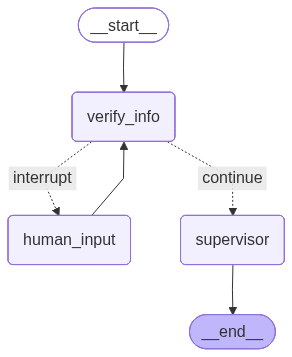

In [26]:
# Initialize a new StateGraph for our multi-agent system with human-in-the-loop verification.
multi_agent_verify = StateGraph(State)

# Add the `verify_info` node for customer identity verification.
multi_agent_verify.add_node("verify_info", verify_info)

# Add the `human_input` node, which triggers an interrupt to get user input.
multi_agent_verify.add_node("human_input", human_input)

# Add the `supervisor` node, which orchestrates the sub-agents for query handling.
multi_agent_verify.add_node("supervisor", supervisor_prebuilt)

# Define the entry point: all interactions start with customer verification.
multi_agent_verify.add_edge(START, "verify_info")

# Define the conditional routing after `verify_info`.
# `should_interrupt` decides whether to continue to the supervisor or prompt for human input.
multi_agent_verify.add_conditional_edges(
    "verify_info",     # Source node
    should_interrupt,  # Conditional function
    {
        # If verification is successful, continue to the main supervisor agent.
        "continue": "supervisor",
        # If verification is needed (or failed), route to `human_input` to prompt the user.
        "interrupt": "human_input",
    },
)

# After `human_input` (once resumed), loop back to `verify_info` to try verification again.
multi_agent_verify.add_edge("human_input", "verify_info")

# The supervisor is the final processing stage before the graph ends.
multi_agent_verify.add_edge("supervisor", END)

# Compile the complete graph, integrating all nodes and edges with our memory systems.
multi_agent_verify_graph = multi_agent_verify.compile(name="multi_agent_verify", checkpointer=checkpointer, store=in_memory_store)

# Display the visualization of the new graph.
show_graph(multi_agent_verify_graph)

In [27]:
thread_id = uuid.uuid4() # Generate a new unique thread ID.

# Initial question without providing customer ID.
question = "How much was my most recent purchase?"

# Configuration for the graph invocation.
config = {"configurable": {"thread_id": thread_id}}

# Invoke the graph. This first invocation should hit the `human_input` node and interrupt.
result = multi_agent_verify_graph.invoke({"messages": [HumanMessage(content=question)]}, config=config)

# Print messages to observe the agent asking for the customer ID.
for message in result["messages"]:
    message.pretty_print()

INFO:httpx:HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


================================ Human Message =================================

How much was my most recent purchase?
================================== Ai Message ==================================

I’m happy to look up that information for you, but I’ll need to verify your account first. Could you please provide one of the following so I can locate your purchase history?

- Your customer ID  
- The email address associated with your account  
- The phone number linked to your account  

Thank you!


In [28]:
from langgraph.types import Command # Import Command for resuming graph execution

# Now, we simulate the user providing their phone number to resume the conversation.
question = "My phone number is +55 (12) 3923-5555."

# Resume from the interrupt using `Command(resume=...)`. 
# The `resume` argument carries the new user input, which gets processed by `human_input` node 
# and then passed back to `verify_info`.
# The `config` must be the same as the initial invocation to resume the correct thread.
result = multi_agent_verify_graph.invoke(Command(resume=question), config=config)

# Print the conversation messages to see the verification and subsequent processing.
for message in result["messages"]:
    message.pretty_print()

INFO:httpx:HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
INFO:groq._base_client:Retrying request to /openai/v1/chat/completions in 6.000000 seconds
INFO:httpx:HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


================================ Human Message =================================

How much was my most recent purchase?
================================== Ai Message ==================================

I’m happy to look up that information for you, but I’ll need to verify your account first. Could you please provide one of the following so I can locate your purchase history?

- Your customer ID  
- The email address associated with your account  
- The phone number linked to your account  

Thank you!
================================ Human Message =================================

My phone number is +55 (12) 3923-5555.
================================ System Message ================================

Thank you for providing your information! I was able to verify your account with customer id 1.
================================== Ai Message ==================================
Name: supervisor
Tool Calls:
  transfer_to_invoice_information_subagent (fc_947a167e-f1f0-40dc-8c41-6f32f513139d)

In [29]:
# Follow-up question in the same thread (using the same `thread_id`).
question = "What albums do you have by the Rolling Stones?"

# Invoke the graph again. Since the `customer_id` is already in the state,
# the verification step will be skipped, and the query will directly go to the supervisor.
result = multi_agent_verify_graph.invoke({"messages": [HumanMessage(content=question)]}, config=config)

# Print the results. You should see the music catalog sub-agent's response directly.
for message in result["messages"]:
    message.pretty_print()

INFO:httpx:HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
INFO:groq._base_client:Retrying request to /openai/v1/chat/completions in 1.000000 seconds
INFO:httpx:HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
INFO:groq._base_client:Retrying request to /openai/v1/chat/completions in 8.000000 seconds
INFO:httpx:HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


================================ Human Message =================================

How much was my most recent purchase?
================================== Ai Message ==================================

I’m happy to look up that information for you, but I’ll need to verify your account first. Could you please provide one of the following so I can locate your purchase history?

- Your customer ID  
- The email address associated with your account  
- The phone number linked to your account  

Thank you!
================================ Human Message =================================

My phone number is +55 (12) 3923-5555.
================================ System Message ================================

Thank you for providing your information! I was able to verify your account with customer id 1.
================================== Ai Message ==================================
Name: supervisor
Tool Calls:
  transfer_to_invoice_information_subagent (fc_947a167e-f1f0-40dc-8c41-6f32f513139d)

In [31]:
from langgraph.store.base import BaseStore # Base class for defining custom stores for LangGraph

# Helper function to format user memory (music preferences) into a readable string.
def format_user_memory(user_data):
    """Formats music preferences from users, if available."""
    profile = user_data['memory'] # Access the 'memory' key from the stored dictionary
    result = "" # Initialize an empty string for the formatted result
    
    # Check if the profile object has a 'music_preferences' attribute and if it's not empty.
    if hasattr(profile, 'music_preferences') and profile.music_preferences:
        # If preferences exist, join them into a comma-separated string.
        result += f"Music Preferences: {', '.join(profile.music_preferences)}"
    
    return result.strip() # Return the formatted string, removing any leading/trailing whitespace.

# Define the `load_memory` node function.
# This node loads a user's long-term memory (music preferences) into the current state.
def load_memory(state: State, config: RunnableConfig, store: BaseStore):
    """Loads music preferences from users, if available."""
    
    user_id = state["customer_id"] # Get the current customer ID from the state.
    namespace = ("memory_profile", user_id) # Define a namespace for storing user-specific memory.
                                          # This creates a unique key for each user's profile.
    
    # Attempt to retrieve existing memory for this user from the `InMemoryStore`.
    existing_memory = store.get(namespace, "user_memory")
    
    formatted_memory = "" # Initialize formatted memory as empty.
    
    # If memory exists and has a value, format it using our helper function.
    if existing_memory and existing_memory.value:
        formatted_memory = format_user_memory(existing_memory.value)

    # Update the `loaded_memory` field in the state with the retrieved and formatted memory.
    return {"loaded_memory" : formatted_memory}

In [32]:
# Define a Pydantic BaseModel to structure the `UserProfile` for long-term memory.
# This ensures that user preferences are stored in a consistent and verifiable format.
class UserProfile(BaseModel):
    # `customer_id`: Required field for the customer's unique identifier.
    customer_id: str = Field(
        description="The customer ID of the customer"
    )
    # `music_preferences`: A list of strings to store the customer's music interests.
    music_preferences: List[str] = Field(
        description="The music preferences of the customer"
    )

In [33]:
# Define the system prompt for the `create_memory` LLM.
# This prompt instructs an LLM to act as an analyst, analyzing conversation history
# to extract and update user music preferences in a structured `UserProfile` format.
create_memory_prompt = """You are an expert analyst that is observing a conversation that has taken place between a customer and a customer support assistant. The customer support assistant works for a digital music store, and has utilized a multi-agent team to answer the customer's request. 
You are tasked with analyzing the conversation that has taken place between the customer and the customer support assistant, and updating the memory profile associated with the customer. The memory profile may be empty. If it's empty, you should create a new memory profile for the customer.

You specifically care about saving any music interest the customer has shared about themselves, particularly their music preferences to their memory profile.

To help you with this task, I have attached the conversation that has taken place between the customer and the customer support assistant below, as well as the existing memory profile associated with the customer that you should either update or create. 

The customer's memory profile should have the following fields:
- customer_id: the customer ID of the customer
- music_preferences: the music preferences of the customer

These are the fields you should keep track of and update in the memory profile. If there has been no new information shared by the customer, you should not update the memory profile. It is completely okay if you do not have new information to update the memory profile with. In that case, just leave the values as they are.

*IMPORTANT INFORMATION BELOW*

The conversation between the customer and the customer support assistant that you should analyze is as follows:
{conversation}

The existing memory profile associated with the customer that you should either update or create based on the conversation is as follows:
{memory_profile}

Ensure your response is an object that has the following fields:
- customer_id: the customer ID of the customer
- music_preferences: the music preferences of the customer

For each key in the object, if there is no new information, do not update the value, just keep the value that is already there. If there is new information, update the value. 

Take a deep breath and think carefully before responding.
"""

# Define the `create_memory` node function.
# This node is responsible for analyzing the conversation and saving/updating user music preferences.
def create_memory(state: State, config: RunnableConfig, store: BaseStore):
    user_id = str(state["customer_id"]) # Get the customer ID from the current state (convert to string).
    namespace = ("memory_profile", user_id) # Define the namespace for this user's memory profile.
    
    # Retrieve the existing memory profile for this user from the long-term store.
    existing_memory = store.get(namespace, "user_memory")
    
    formatted_memory = "" # Initialize formatted memory for the prompt.
    if existing_memory and existing_memory.value:
        existing_memory_dict = existing_memory.value # Get the dictionary containing the UserProfile instance.
        # Format existing music preferences into a string for the prompt.
        formatted_memory = (
            f"Music Preferences: {', '.join(existing_memory_dict.get('memory').music_preferences or [])}" # Access the UserProfile object via 'memory' key
        )

    # Create a SystemMessage with the formatted prompt, injecting the full conversation history
# and the existing memory profile.
    formatted_system_message = SystemMessage(content=create_memory_prompt.format(conversation=state["messages"], memory_profile=formatted_memory))
    
    # Invoke the LLM with structured output (`UserProfile`) to analyze the conversation
    # and update the memory profile based on new information.
    updated_memory = llm.with_structured_output(UserProfile).invoke([formatted_system_message])
    
    key = "user_memory" # Define the key for storing this specific memory object.
    
    # Store the updated memory profile back into the `InMemoryStore`.
    # We wrap `updated_memory` in a dictionary under the key 'memory' for consistency in access.
    store.put(namespace, key, {"memory": updated_memory})

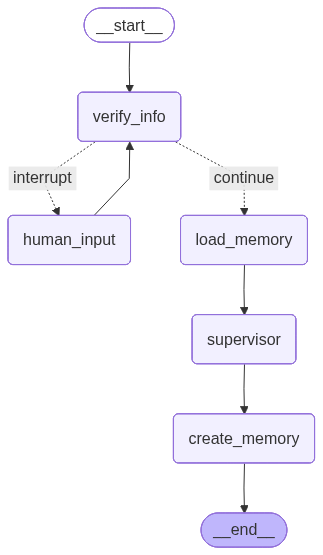

In [34]:
# Initialize the final StateGraph for our complete multi-agent system, including memory management.
multi_agent_final = StateGraph(State)

# Add all necessary nodes to the graph.
multi_agent_final.add_node("verify_info", verify_info)         # Node for customer verification
multi_agent_final.add_node("human_input", human_input)         # Node for human-in-the-loop interruption
multi_agent_final.add_node("load_memory", load_memory)         # Node for loading user long-term memory
multi_agent_final.add_node("supervisor", supervisor_prebuilt) # Supervisor for routing to sub-agents
multi_agent_final.add_node("create_memory", create_memory)     # Node for saving/updating user long-term memory

# Define the initial entry point: all interactions start with verification.
multi_agent_final.add_edge(START, "verify_info")

# Define the conditional routing after `verify_info`.
# If verification is successful, proceed to load memory. Otherwise, prompt for human input.
multi_agent_final.add_conditional_edges(
    "verify_info",
    should_interrupt,
    {
        "continue": "load_memory", # If verified, load user memory
        "interrupt": "human_input", # If not verified, request human input
    },
)

# After `human_input` (resume), loop back to `verify_info` to re-attempt verification.
multi_agent_final.add_edge("human_input", "verify_info")

# After loading memory, proceed to the supervisor for main query processing.
multi_agent_final.add_edge("load_memory", "supervisor")

# After the supervisor completes, save/update the user's memory.
multi_agent_final.add_edge("supervisor", "create_memory")

# The graph ends after memory has been updated.
multi_agent_final.add_edge("create_memory", END)

# Compile the entire, sophisticated graph.
multi_agent_final_graph = multi_agent_final.compile(name="multi_agent_verify", checkpointer=checkpointer, store=in_memory_store)

# Display the visualization of the complete graph.
show_graph(multi_agent_final_graph)

In [35]:
thread_id = uuid.uuid4() # Generate a fresh unique thread ID for this demonstration.

# A comprehensive question that includes customer ID, invoice query, and music preference.
question = "My phone number is +55 (12) 3923-5555. How much was my most recent purchase? What albums do you have by the Rolling Stones?"

# Configuration for the graph invocation.
# Note: The user_id is passed as a configurable parameter, although in this specific example,
# the customer_id is extracted dynamically by the verify_info node. 
# For real-world use, ensure consistent handling of user identifiers.
config = {"configurable": {"thread_id": thread_id, "user_id" : "1"}}

# Invoke the final multi-agent graph.
# This will run through verification, memory loading, supervisor routing (to invoice then music),
# and finally memory saving.
result = multi_agent_final_graph.invoke({"messages": [HumanMessage(content=question)]}, config=config)

# Print all messages in the final state to observe the complete interaction flow.
for message in result["messages"]:
    message.pretty_print()

INFO:httpx:HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
INFO:groq._base_client:Retrying request to /openai/v1/chat/completions in 21.000000 seconds
INFO:httpx:HTTP Request: POST

================================ Human Message =================================

My phone number is +55 (12) 3923-5555. How much was my most recent purchase? What albums do you have by the Rolling Stones?
================================ System Message ================================

Thank you for providing your information! I was able to verify your account with customer id 1.
================================== Ai Message ==================================
Name: supervisor
Tool Calls:
  transfer_to_invoice_information_subagent (fc_4e4f515f-08c9-4159-af17-3d3d036b9ce2)
 Call ID: fc_4e4f515f-08c9-4159-af17-3d3d036b9ce2
  Args:
    customer_id: 1
================================= Tool Message =================================
Name: transfer_to_invoice_information_subagent

Successfully transferred to invoice_information_subagent
================================== Ai Message ==================================
Name: invoice_information_subagent

Your most recent purchase (invoice #382 d

In [36]:
user_id = "1" # The customer ID we expect to be associated with the phone number used.
namespace = ("memory_profile", user_id) # The namespace used to store this user's memory.

# Retrieve the user's memory profile from the `in_memory_store`.
# `.value` retrieves the actual data stored, which should be a dictionary containing the UserProfile instance.
memory_data = in_memory_store.get(namespace, "user_memory")

# Check if memory_data exists and has a 'memory' key (which holds the UserProfile object).
if memory_data and "memory" in memory_data.value:
    saved_music_preferences = memory_data.value.get("memory").music_preferences
else:
    saved_music_preferences = [] # Default to empty list if no preferences found.

print(f"Saved Music Preferences for Customer ID {user_id}: {saved_music_preferences}")

Saved Music Preferences for Customer ID 1: ['Rolling Stones']


C:\Users\SNA\AppData\Local\Temp\ipykernel_34156\3965639398.py:25: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  invoice_information_agent_with_handoff = create_react_agent(
C:\Users\SNA\AppData\Local\Temp\ipykernel_34156\3965639398.py:34: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  music_catalog_agent_with_handoff = create_react_agent(


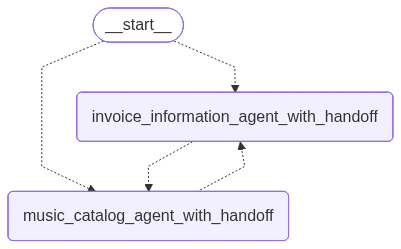

In [37]:
from langgraph_swarm import create_handoff_tool, create_swarm # Import utilities for creating swarm agents and handoff tools

# Create our handoff tools between agents.
# These are special tools that, when called by an agent, signal a transfer of control
# to another named agent within the swarm.

transfer_to_invoice_agent_handoff_tool = create_handoff_tool(
    agent_name = "invoice_information_agent_with_handoff", # The name of the target agent for this handoff
    description = "Transfer user to the invoice information agent that can help with invoice information" # Description for LLM
)

transfer_to_music_catalog_agent_handoff_tool = create_handoff_tool(
    agent_name = "music_catalog_agent_with_handoff", 
    description = "Transfer user to the music catalog agent that can help with music searches and music catalog information"
)

# Recreate our agents, but this time, add the handoff tools to their available tools.
# This allows each agent to `request` a handoff to the other when appropriate.

# First, combine the handoff tools with the existing specific tools for each agent.
invoice_tools_with_handoff = [transfer_to_music_catalog_agent_handoff_tool] + invoice_tools
music_tools_with_handoff = [transfer_to_invoice_agent_handoff_tool] + music_tools

# Recreate the invoice information agent with its original prompt and its new set of tools (including handoff).
invoice_information_agent_with_handoff = create_react_agent(
    llm,
    invoice_tools_with_handoff,
    prompt = invoice_subagent_prompt,
    name = "invoice_information_agent_with_handoff" # Give it a specific name for the swarm
)

# Recreate the music catalog agent with its original prompt and its new set of tools (including handoff).
# Note: The music catalog agent prompt is generated dynamically, as defined earlier.
music_catalog_agent_with_handoff = create_react_agent(
    llm,
    music_tools_with_handoff,
    prompt = generate_music_assistant_prompt(),
    name = "music_catalog_agent_with_handoff" # Give it a specific name for the swarm
)


# Create the swarm workflow. `create_swarm` handles the orchestration logic
# for agents to hand off to each other without a central supervisor.
swarm_workflow = create_swarm(
    agents = [invoice_information_agent_with_handoff, music_catalog_agent_with_handoff], # The agents participating in the swarm
    default_active_agent = "invoice_information_agent_with_handoff", # The agent that will be active first by default
)

# Compile the swarm graph. This makes it runnable and integrates memory.
swarm_agents = swarm_workflow.compile(
    checkpointer = checkpointer,
    store = in_memory_store
)

# Display the graph of the swarm. Notice it's different from the supervisor graph,
# showing connections for potential handoffs rather than a central hub.
show_graph(swarm_agents)

In [38]:
# Create a new thread for this swarm test.
thread_id = uuid.uuid4()

# Ask a music-related question.
question = "Do you have any albums by the Rolling Stones?"

# Configure the invocation with the thread ID.
config = {"configurable": {"thread_id": thread_id}}

# Invoke the swarm agents. Even though the default active agent is `invoice_information_agent_with_handoff`,
# it should recognize that the query is for music and hand off to `music_catalog_agent_with_handoff`.
result = swarm_agents.invoke({"messages": [HumanMessage(content=question)]}, config=config)

# Print the messages to observe the handoff and the final response.
for message in result["messages"]:
    message.pretty_print()

INFO:httpx:HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


================================ Human Message =================================

Do you have any albums by the Rolling Stones?
================================== Ai Message ==================================
Name: invoice_information_agent_with_handoff
Tool Calls:
  transfer_to_music_catalog_agent_with_handoff (fc_98403d87-afd9-4c0c-929c-5145fb6a7562)
 Call ID: fc_98403d87-afd9-4c0c-929c-5145fb6a7562
  Args:
================================= Tool Message =================================
Name: transfer_to_music_catalog_agent_with_handoff

Successfully transferred to music_catalog_agent_with_handoff
================================== Ai Message ==================================
Name: music_catalog_agent_with_handoff
Tool Calls:
  get_albums_by_artist (fc_19cb47a0-71b5-438d-aa3a-f1b727fc27a5)
 Call ID: fc_19cb47a0-71b5-438d-aa3a-f1b727fc27a5
  Args:
    artist: Rolling Stones
================================= Tool Message =================================
Name: get_albums_by_artist

[{